# import libraries

In [167]:
import pandas as pd
import pickle
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, cohen_kappa_score, confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
import umap
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import silhouette_samples, silhouette_score

# variables

In [2]:
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
S1_BANDS = ['VV', 'VH']

# TRAIN_COUNTRIES = ['at', 'ee', 'bg']  
# TEST_COUNTRIES  = ['ie', 'be', 'dk']   
TRAIN_COUNTRIES = ['at', 'ie', 'dk']  
TEST_COUNTRIES  = ['ee', 'bg', 'be']      

# opening datasets

In [3]:
def load_raw_datasets(data_dir):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.pkl')):
        stem  = filepath.stem                      
        parts = stem.rsplit('_', 3)                

        if len(parts) != 4 or parts[3] != 'image':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        with open(filepath, 'rb') as f:
            data = pickle.load(f)

        datasets[f"{crop}_{country}_{year}"] = data
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(data)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [4]:
raw_data = load_raw_datasets('_data/exports/image_points_exports')

Loaded maize_corn_popcorn_at_2019_image.pkl → country=at | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_be_2019_image.pkl → country=be | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_bg_2019_image.pkl → country=bg | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_dk_2019_image.pkl → country=dk | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ee_2019_image.pkl → country=ee | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ie_2019_image.pkl → country=ie | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded potatoes_at_2019_image.pkl → country=at | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_be_2019_image.pkl → country=be | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_bg_2019_image.pkl → country=bg | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_dk_2019_image.pkl → country=dk | crop=potatoes | year=2019 | 50

In [5]:
raw_data.keys()

dict_keys(['maize_corn_popcorn_at_2019', 'maize_corn_popcorn_be_2019', 'maize_corn_popcorn_bg_2019', 'maize_corn_popcorn_dk_2019', 'maize_corn_popcorn_ee_2019', 'maize_corn_popcorn_ie_2019', 'potatoes_at_2019', 'potatoes_be_2019', 'potatoes_bg_2019', 'potatoes_dk_2019', 'potatoes_ee_2019', 'potatoes_ie_2019', 'winter_barley_at_2019', 'winter_barley_be_2019', 'winter_barley_bg_2019', 'winter_barley_dk_2019', 'winter_barley_ee_2019', 'winter_barley_ie_2019'])

In [6]:
def load_embedding_datasets(data_dir):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.parquet')):
        stem  = filepath.stem                      
        parts = stem.rsplit('_', 3)                

        if len(parts) != 4 or parts[3] != 'embedding':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        df = pd.read_parquet(filepath)
        df['crop']    = crop
        df['country'] = country
        df['year']    = year

        datasets[f"{crop}_{country}_{year}"] = df
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(df)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [7]:
embedding_data = load_embedding_datasets('_data/exports/embeddings_exports')

Loaded maize_corn_popcorn_at_2019_embedding.parquet → country=at | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_be_2019_embedding.parquet → country=be | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_bg_2019_embedding.parquet → country=bg | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_dk_2019_embedding.parquet → country=dk | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ee_2019_embedding.parquet → country=ee | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ie_2019_embedding.parquet → country=ie | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_pt_2019_embedding.parquet → country=pt | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded potatoes_at_2019_embedding.parquet → country=at | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_be_2019_embedding.parquet → country=be | crop=potatoes | year=2019 |

In [8]:
embedding_data.keys()

dict_keys(['maize_corn_popcorn_at_2019', 'maize_corn_popcorn_be_2019', 'maize_corn_popcorn_bg_2019', 'maize_corn_popcorn_dk_2019', 'maize_corn_popcorn_ee_2019', 'maize_corn_popcorn_ie_2019', 'maize_corn_popcorn_pt_2019', 'potatoes_at_2019', 'potatoes_be_2019', 'potatoes_bg_2019', 'potatoes_dk_2019', 'potatoes_ee_2019', 'potatoes_ie_2019', 'potatoes_pt_2019', 'winter_barley_at_2019', 'winter_barley_be_2019', 'winter_barley_bg_2019', 'winter_barley_dk_2019', 'winter_barley_ee_2019', 'winter_barley_ie_2019'])

In [9]:
embedding_data['maize_corn_popcorn_at_2019'].head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,15.95,48.65,628,638,EPSG:32633,"[3.0008357, 1.5298377, 4.059954, 7.472669, 3.2...","[15.985727711616656, 48.64358116680461]",maize_corn_popcorn,at,2019,at
1,16.55,47.95,240,355,EPSG:32633,"[4.665599, 1.133074, 2.932662, 4.7989016, 3.33...","[16.546969834985113, 47.979056503789096]",maize_corn_popcorn,at,2019,at
2,13.95,48.25,37,126,EPSG:32633,"[3.1382673, -0.12553069, 2.510614, 3.263798, 1...","[13.915045903720529, 48.296755844896495]",maize_corn_popcorn,at,2019,at


# classifiers

In [10]:
models = {'LogisticRegression': Pipeline([('scaler', StandardScaler()), 
                                          ('clf', LogisticRegression(max_iter=1000, random_state=42))]), 
          'RandomForest': Pipeline([('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])}


def evaluate_model(name, pipeline, x_train, y_train, x_test, y_test):
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    print(f"--{name}--")
    print(classification_report(y_test, y_pred))

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return pipeline, accuracy , f1, kappa, y_pred

# raw data

## compute indices

In [11]:
def compute_s1_indices(s1):
    s1  = s1.copy()
    eps = 1e-8
    s1['VV_VH_ratio'] = s1['VV'] / (s1['VH'] + eps)
    s1['RVI']         = 4 * s1['VH'] / (s1['VV'] + s1['VH'] + eps)
    return s1

In [12]:
def compute_s2_indices(s2):
    s2  = s2.copy()
    eps = 1e-8
    s2['NDVI'] = (s2['B8']  - s2['B4']) / (s2['B8']  + s2['B4'] + eps)
    s2['NDWI'] = (s2['B3']  - s2['B8']) / (s2['B3']  + s2['B8'] + eps)
    s2['NDRE'] = (s2['B8']  - s2['B5']) / (s2['B8']  + s2['B5'] + eps)
    s2['EVI']  = 2.5 * (s2['B8'] - s2['B4']) / (s2['B8'] + 6*s2['B4'] - 7.5*s2['B2'] + 1 + eps)
    return s2

In [13]:
raw_data['potatoes_at_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date
0,16.083572,48.393816,-4.416768,-15.207887,2019-01-02 05:09:54
1,16.083572,48.393816,-4.596389,-13.355788,2019-01-02 05:09:56


In [14]:
raw_data['potatoes_at_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date
0,16.083572,48.393816,8808,8528,8440,9478,9163,9072,8800,8963,4132,3890,2019-01-01 10:07:13
1,16.083572,48.393816,5772,5160,4940,5017,4869,4788,5116,4691,3009,2647,2019-01-03 09:57:19


In [15]:
for key in raw_data.keys():
    crop_country_year = raw_data[key]
    for i in range(len(crop_country_year)):
        s1 = crop_country_year[i]['s1']
        s2 = crop_country_year[i]['s2']
        raw_data[key][i]['s1'] = compute_s1_indices(s1)
        raw_data[key][i]['s2'] = compute_s2_indices(s2)

In [16]:
raw_data['potatoes_at_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date,VV_VH_ratio,RVI
0,16.083572,48.393816,-4.416768,-15.207887,2019-01-02 05:09:54,0.290426,3.099751
1,16.083572,48.393816,-4.596389,-13.355788,2019-01-02 05:09:56,0.344150,2.975859


In [17]:
raw_data['potatoes_at_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date,NDVI,NDWI,NDRE,EVI
0,16.083572,48.393816,8808,8528,8440,9478,9163,9072,8800,8963,4132,3890,2019-01-01 10:07:13,0.020882,-0.015697,-0.037094,-0.135972
1,16.083572,48.393816,5772,5160,4940,5017,4869,4788,5116,4691,3009,2647,2019-01-03 09:57:19,0.017502,0.004282,0.009770,-0.051565


## agregate data and feature engineering on data

In [18]:
def aggregate_monthly_s1(df):
    feat_df = df[['VV', 'VH', 'VV_VH_ratio', 'RVI']].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [19]:
def aggregate_monthly_s2(df):
    s2_bands   = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
    s2_indices = ['NDVI','NDWI','NDRE','EVI']
    
    feat_df = df[s2_bands + s2_indices].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [20]:
def fit_harmonics(df, feature):
    doy = pd.to_datetime(df['date']).dt.dayofyear.values
    values = df[feature].values
    
    t = 2 * np.pi * doy / 365
    X = np.column_stack([
        np.ones_like(t),
        np.cos(t), np.sin(t),      # annual cycle
        np.cos(2*t), np.sin(2*t)   # semi annual cycle
    ])
    
    coeffs, _, _, _ = np.linalg.lstsq(X, values, rcond=None)
    
    offset      = coeffs[0]
    amplitude_1 = np.sqrt(coeffs[1]**2 + coeffs[2]**2)
    phase_1     = np.arctan2(coeffs[2], coeffs[1])
    amplitude_2 = np.sqrt(coeffs[3]**2 + coeffs[4]**2)
    phase_2     = np.arctan2(coeffs[4], coeffs[3])
    
    return offset, amplitude_1, phase_1, amplitude_2, phase_2

In [21]:
def extract_harmonic_features(s1_df, s2_df):
    features = {}
    
    for feat in ['NDVI', 'EVI', 'NDRE', 'NDWI']:
        o, a1, p1, a2, p2 = fit_harmonics(s2_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    for feat in ['VV', 'VH', 'RVI']:
        o, a1, p1, a2, p2 = fit_harmonics(s1_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    return pd.Series(features)

In [22]:
# rows = []

# for key, points_list in raw_data.items():
#     parts = key.split("_")
#     label = "_".join(parts[:-2])
#     country = parts[-2]
    
#     for point in points_list:
#         row_s1 = aggregate_monthly_s1(point['s1'])
#         row_s2 = aggregate_monthly_s2(point['s2'])
#         harmonic_row = extract_harmonic_features(point['s1'], point['s2'])
        
#         lat = point['point_coord'][1]
#         lon = point['point_coord'][0]
        
#         combined_row = pd.concat([row_s1, row_s2, harmonic_row])
#         combined_row['latitude']  = lat
#         combined_row['longitude'] = lon
#         combined_row['country'] = country
#         combined_row['crop'] = label
        
#         rows.append(combined_row)

# raw_df = pd.DataFrame(rows).reset_index(drop=True)

In [23]:
rows = []

for key, points_list in raw_data.items():
    parts = key.split("_")
    label = "_".join(parts[:-2])
    country = parts[-2]
    
    for point in points_list:
        row_s1 = aggregate_monthly_s1(point['s1'])
        row_s2 = aggregate_monthly_s2(point['s2'])
        # harmonic_row = extract_harmonic_features(point['s1'], point['s2'])
        
        lat = point['point_coord'][1]
        lon = point['point_coord'][0]
        
        # combined_row = pd.concat([row_s1, row_s2, harmonic_row])
        combined_row = pd.concat([row_s1, row_s2])
        combined_row['latitude']  = lat
        combined_row['longitude'] = lon
        combined_row['country'] = country
        combined_row['crop'] = label
        
        rows.append(combined_row)

raw_df = pd.DataFrame(rows).reset_index(drop=True)

In [24]:
print(f"Shape of raw df: {raw_df.shape}")
print(f"Crops on raw df: {raw_df['crop'].unique()}")
print(f"Countries on raw df: {raw_df['country'].unique()}")

Shape of raw df: (9000, 436)
Crops on raw df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Countries on raw df: ['at' 'be' 'bg' 'dk' 'ee' 'ie']


## split train test

In [25]:
raw_train_df = raw_df[raw_df['country'].isin(TRAIN_COUNTRIES)].reset_index(drop=True)
raw_test_df  = raw_df[raw_df['country'].isin(TEST_COUNTRIES)].reset_index(drop=True)

In [26]:
# drop columns
drop_cols = ['latitude', 'longitude', 'crop', 'country']

raw_x_train = raw_train_df.drop(columns=drop_cols)
raw_y_train = raw_train_df['crop']

raw_x_test  = raw_test_df.drop(columns=drop_cols)
raw_y_test  = raw_test_df['crop']

print(f"Train shape for raw: {raw_x_train.shape}")
print(f"Test shape for raw: {raw_x_test.shape}")

Train shape for raw: (4500, 432)
Test shape for raw: (4500, 432)


In [27]:
# check Nan values
print(f"Nan values before for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values before for raw_x_text: {raw_x_test.isnull().sum().sum()}")   

raw_x_train = raw_x_train.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean())
raw_x_test  = raw_x_test.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean()) 

print(f"Nan values after for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values after for raw_x_text: {raw_x_test.isnull().sum().sum()}")   

Nan values before for raw_x_train: 0
Nan values before for raw_x_text: 0
Nan values after for raw_x_train: 0
Nan values after for raw_x_text: 0


## apply models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.78      0.84      0.81      1500
          potatoes       0.69      0.72      0.71      1500
     winter_barley       0.90      0.79      0.84      1500

          accuracy                           0.78      4500
         macro avg       0.79      0.78      0.79      4500
      weighted avg       0.79      0.78      0.79      4500



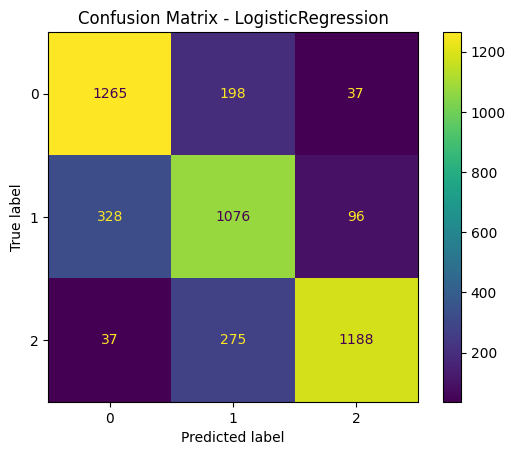

In [28]:
# logistic regression
lr_raw, lr_raw_accuracy, lr_raw_f1, lr_raw_kappa, lr_raw_y_pred = evaluate_model('LogisticRegression', 
                        models['LogisticRegression'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.94      0.64      0.76      1500
          potatoes       0.67      0.94      0.78      1500
     winter_barley       0.96      0.87      0.91      1500

          accuracy                           0.82      4500
         macro avg       0.86      0.82      0.82      4500
      weighted avg       0.86      0.82      0.82      4500



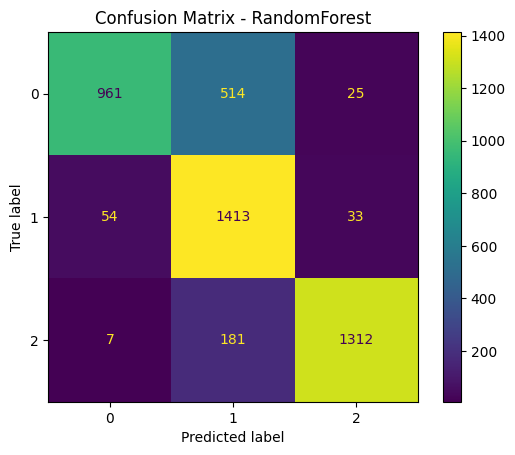

In [29]:
# random forest
rf_raw, rf_raw_accuracy, rf_raw_f1, rf_raw_kappa, rf_raw_y_pred = evaluate_model('RandomForest', 
                        models['RandomForest'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

# embeddings data

## pre processing

In [30]:
embeddings_df = pd.concat(embedding_data.values(), ignore_index=True)

print(f"Original embeddings shape: {embeddings_df.shape}")
print(f"Embedding length: {len(embeddings_df['embedding'].iloc[0])}")  

Original embeddings shape: (10000, 11)
Embedding length: 128


In [31]:
embeddings_df.head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,15.95,48.65,628.0,638.0,EPSG:32633,"[3.0008357, 1.5298377, 4.059954, 7.472669, 3.2...","[15.985727711616656, 48.64358116680461]",maize_corn_popcorn,at,2019,at
1,16.55,47.95,240.0,355.0,EPSG:32633,"[4.665599, 1.133074, 2.932662, 4.7989016, 3.33...","[16.546969834985113, 47.979056503789096]",maize_corn_popcorn,at,2019,at
2,13.95,48.25,37.0,126.0,EPSG:32633,"[3.1382673, -0.12553069, 2.510614, 3.263798, 1...","[13.915045903720529, 48.296755844896495]",maize_corn_popcorn,at,2019,at


In [32]:
# drop whats no necessary
embeddings_df = embeddings_df.drop(columns=['tile_lon', 'tile_lat', 'pixel_row', 'pixel_col', 'crs', 'country_id', 'year'])
embeddings_df = embeddings_df[embeddings_df['country'] != 'pt'].reset_index(drop=True)
print(f"Processed embeddings shape: {embeddings_df.shape}")

Processed embeddings shape: (9000, 4)


In [33]:
embeddings_df.head(3)

,embedding,long_lat,crop,country
0,"[3.0008357, 1.5298377, 4.059954, 7.472669, 3.2...","[15.985727711616656, 48.64358116680461]",maize_corn_popcorn,at
1,"[4.665599, 1.133074, 2.932662, 4.7989016, 3.33...","[16.546969834985113, 47.979056503789096]",maize_corn_popcorn,at
2,"[3.1382673, -0.12553069, 2.510614, 3.263798, 1...","[13.915045903720529, 48.296755844896495]",maize_corn_popcorn,at


In [72]:
# expand the embeddings to features
emb_df = pd.DataFrame(embeddings_df['embedding'].tolist(), 
                             columns=[f'emb_{i}' for i in range(len(embeddings_df['embedding'].iloc[0]))])

emb_df['latitude']  = embeddings_df['long_lat'].apply(lambda x: x[1])
emb_df['longitude'] = embeddings_df['long_lat'].apply(lambda x: x[0])
emb_df['crop']      = embeddings_df['crop']
emb_df['country']   = embeddings_df['country']

print(f"Final embeddings shape: {embeddings_df.shape}")

Final embeddings shape: (9000, 4)


## split train test

In [36]:
emb_train_df = emb_df[emb_df['country'].isin(TRAIN_COUNTRIES)].reset_index(drop=True)
emb_test_df  = emb_df[emb_df['country'].isin(TEST_COUNTRIES)].reset_index(drop=True)

In [37]:
drop_cols = ['latitude', 'longitude', 'crop', 'country']

emb_x_train = emb_train_df.drop(columns=drop_cols)
emb_y_train = emb_train_df['crop']

emb_x_test  = emb_test_df.drop(columns=drop_cols)
emb_y_test  = emb_test_df['crop']

print(f"Train shape for embeddigns: {emb_x_train.shape}")
print(f"Test shape for embeddings: {emb_x_test.shape}")

Train shape for embeddigns: (4500, 128)
Test shape for embeddings: (4500, 128)


In [38]:
# check Nan values
print(f"Nan values before for emb_x_train: {emb_x_train.isnull().sum().sum()}")  
print(f"Nan values before for emb_x_text: {emb_x_test.isnull().sum().sum()}")   

emb_x_train = emb_x_train.fillna(0)
emb_x_test  = emb_x_test.fillna(0)

print(f"Nan values after for emb_x_train: {emb_x_train.isnull().sum().sum()}")  
print(f"Nan values after for emb_x_text: {emb_x_test.isnull().sum().sum()}")   

Nan values before for emb_x_train: 896
Nan values before for emb_x_text: 0
Nan values after for emb_x_train: 0
Nan values after for emb_x_text: 0


In [39]:
print(f"Train shape for embeddigns: {emb_x_train.shape}")
print(f"Test shape for embeddings: {emb_x_test.shape}")

Train shape for embeddigns: (4500, 128)
Test shape for embeddings: (4500, 128)


## apply models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.88      0.87      0.87      1500
          potatoes       0.82      0.87      0.84      1500
     winter_barley       0.91      0.87      0.89      1500

          accuracy                           0.87      4500
         macro avg       0.87      0.87      0.87      4500
      weighted avg       0.87      0.87      0.87      4500



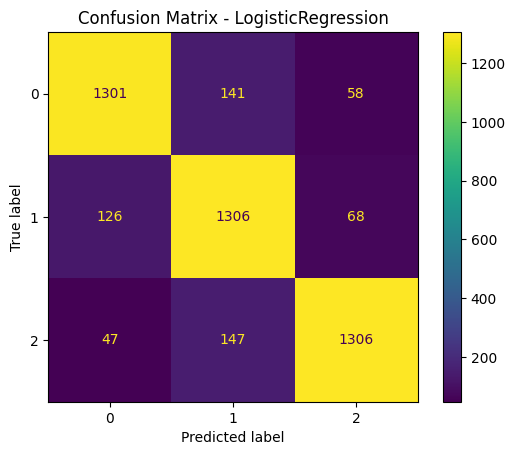

In [40]:
# logistic regression
lr_emb, lr_emb_accuracy, lr_emb_f1, lr_emb_kappa, lr_emb_y_pred = evaluate_model('LogisticRegression', 
                        models['LogisticRegression'], 
                        emb_x_train, emb_y_train, emb_x_test, emb_y_test)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.97      0.86      0.91      1500
          potatoes       0.81      0.95      0.88      1500
     winter_barley       0.96      0.90      0.93      1500

          accuracy                           0.90      4500
         macro avg       0.91      0.90      0.90      4500
      weighted avg       0.91      0.90      0.90      4500



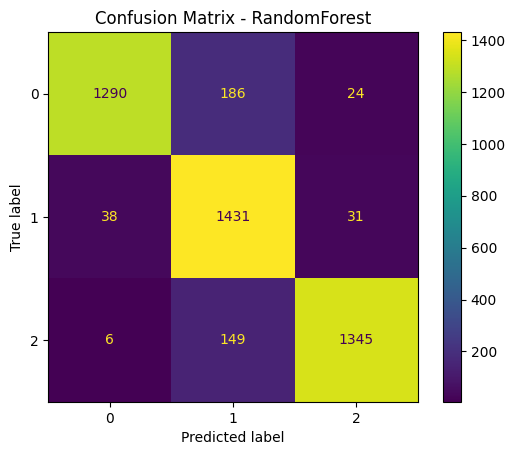

In [41]:
# random forest
rf_emb, rf_emb_accuracy, rf_emb_f1, rf_emb_kappa, rf_emb_y_pred = evaluate_model('RandomForest', 
                        models['RandomForest'], 
                        emb_x_train, emb_y_train, emb_x_test, emb_y_test)

# analysis

## basic metrics

In [42]:
print(f"For LogisticRegression with raw data, \n accuracy = {lr_raw_accuracy:.2f} \n f1_macro = {lr_raw_f1:.2f} \n kappa = {lr_raw_kappa:.2f}")
print(f"For RandomForest with raw data, \n accuracy = {rf_raw_accuracy:.2f} \n f1_macro = {rf_raw_f1:.2f} \n kappa = {rf_raw_kappa:.2f}")
print(f"For LogisticRegression with embedding data, \n accuracy = {lr_emb_accuracy:.2f} \n f1_macro = {lr_emb_f1:.2f} \n kappa = {lr_emb_kappa:.2f}")
print(f"For RandomForest with embedding data, \n accuracy = {rf_emb_accuracy:.2f} \n f1_macro = {rf_emb_f1:.2f} \n kappa = {rf_emb_kappa:.2f}")

For LogisticRegression with raw data, 
 accuracy = 0.78 
 f1_macro = 0.79 
 kappa = 0.68
For RandomForest with raw data, 
 accuracy = 0.82 
 f1_macro = 0.82 
 kappa = 0.73
For LogisticRegression with embedding data, 
 accuracy = 0.87 
 f1_macro = 0.87 
 kappa = 0.80
For RandomForest with embedding data, 
 accuracy = 0.90 
 f1_macro = 0.90 
 kappa = 0.86


## spatial visual analysis

In [87]:
def reducer(data, n_components=2, method='umap'):
    if method == "umap":
        reducer = umap.UMAP(n_components=n_components, 
                            n_neighbors=30, 
                            min_dist=0.1, 
                            metric='cosine', 
                            random_state=42)
    elif method == "pca":
        reducer = PCA(n_components=n_components)
    elif method == "tsne":
        reducer = TSNE(n_components=n_components, 
                       perplexity=50, 
                       learning_rate='auto', 
                       init='pca', 
                       metric='cosine', 
                       random_state=42)
    
    data_2d = reducer.fit_transform(data)
    return data_2d

In [114]:
def plot_embedding_space(data, labels, method='umap'):
    data_2d = reducer(data.values, method=method)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # color by crop
    crops = labels['crop'].unique()
    
    ax = axes[0]
    for crop in crops:
        mask = labels['crop'] == crop
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], label=crop, alpha=0.5, s=10)
    ax.set_title('Colored by Crop')
    ax.legend()
    
    # color by country
    countries = labels['country'].unique()
    
    ax = axes[1]
    for i, country in enumerate(countries):
        mask = labels['country'] == country
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], label=country, alpha=0.5, s=10)
    ax.set_title('Colored by Country')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return data_2d

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


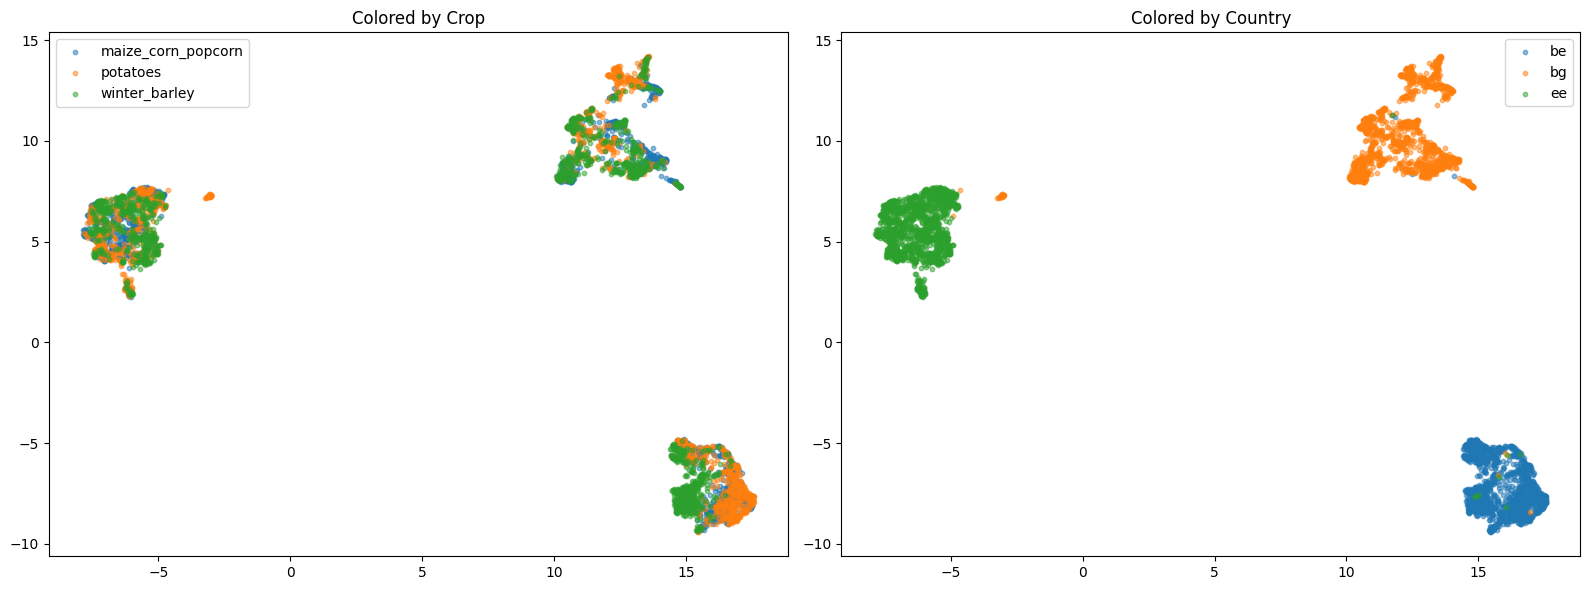

In [115]:
# raw test
emb_2d = plot_embedding_space(raw_x_test, 
                              raw_test_df, 
                              method='umap')

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


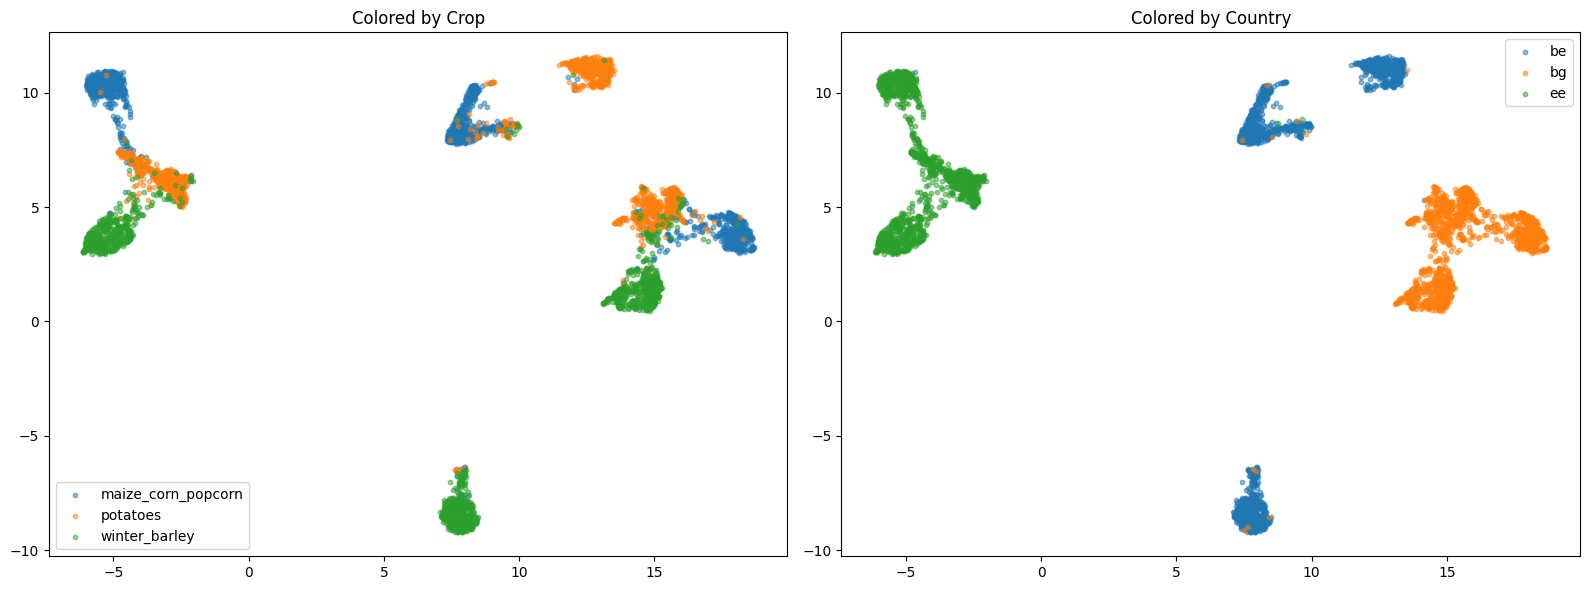

In [116]:
# embeddings test
emb_2d = plot_embedding_space(emb_x_test, 
                              emb_test_df,
                              method='umap')

## comparing embeddings metrics

**COSINE SIMILARITY** Measures the angle between two vectors. Direction matters, magnitude does not. Ignores scale differences between countries, captures pattern/direction. 
- oposite meaning -1
- unrealated 0
- super related 1

**EUCLIDEAN DISTANCE** Measures straight-line distance between two points. Both direction AND magnitude matter so scaler is important.
- identical/very close 0
- very far/super different ∞

**SILHOUETE** Measures how well a point fits its own cluster vs the nearest other cluster. A per-point score, averaged. Use to evaluate overall cluster quality. Works with any distance metric, which is why you should pass `metric='cosine'` for embeddings.
- in the wrong cluster -1
- on boudary 0
- perfectly separated 1

In [ ]:
def cosine_similarity_metric(data, labels, evaluate='crop'):
    metric = cosine_similarity(data.values)
    evaluate_labels = labels[evaluate].reset_index(drop=True).values
    evaluations = np.unique(evaluate_labels)
    for evaluation in evaluations:
        mask = evaluate_labels == evaluation
        intra = metric[np.ix_(mask, mask)] # same class
        np.fill_diagonal(intra, np.nan)
        inter = metric[np.ix_(mask, ~mask)] # different class
        print(f"For {evaluation}: same class={np.nanmean(intra):.3f}, different class={inter.mean():.3f}")
    return metric

def euclidean_distances_metric(data, labels, evaluate='crop'):
    scaler = StandardScaler()
    metric = euclidean_distances(scaler.fit_transform(data.values))
    evaluate_labels = labels[evaluate].reset_index(drop=True).values
    evaluations = np.unique(evaluate_labels)
    for evaluation in evaluations:
        mask = evaluate_labels == evaluation
        intra = metric[np.ix_(mask, mask)] # same class
        np.fill_diagonal(intra, np.nan)
        inter = metric[np.ix_(mask, ~mask)] # different class
        print(f"For {evaluation}: same class={np.nanmean(intra):.3f}, different class={inter.mean():.3f}")
    return metric

def silhouete_metric(data, labels, evaluate='crop'):
    evaluate_labels = labels[evaluate].reset_index(drop=True).values
    
    score = silhouette_score(data, evaluate_labels, metric='cosine')
    print(f"Overall silhouette by {evaluate}: {score:.3f}")
    
    sample_scores = silhouette_samples(data.values, evaluate_labels, metric='cosine')
    
    for label in np.unique(evaluate_labels):
        mask = evaluate_labels == label
        print(f"  {label}: {sample_scores[mask].mean():.3f}")
    return score


def plot_metrics(data, labels):
    crop_labels    = labels['crop'].reset_index(drop=True).values
    country_labels = labels['country'].reset_index(drop=True).values
    
    sort_idx = np.lexsort((country_labels, crop_labels))
    sorted_data    = data[np.ix_(sort_idx, sort_idx)]
    sorted_crops   = crop_labels[sort_idx]
    sorted_countries = country_labels[sort_idx]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(sorted_data, aspect='auto')
    plt.colorbar(im, ax=ax)
    
    tick_positions = []
    tick_labels    = []
    i = 0
    while i < len(sorted_crops):
        j = i
        while j < len(sorted_crops) and sorted_crops[j] == sorted_crops[i] and sorted_countries[j] == sorted_countries[i]:
            j += 1
        center = (i + j - 1) / 2
        tick_positions.append(center)
        tick_labels.append(f"{sorted_crops[i]}\n({sorted_countries[i]})")
        i = j
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, fontsize=8)
    
    plt.tight_layout()
    plt.show()


In [200]:
datasets = {
    'Embeddings': (emb_x_test, emb_test_df),
    'Raw Features': (raw_x_test, raw_test_df)
}

metrics = {
    'Cosine Similarity':   cosine_similarity_metric,
    'Euclidean Distance':  euclidean_distances_metric,
}

for data_name, (data, labels) in datasets.items():
    for metric_name, metric_fn in metrics.items():
        print(f"\n{'='*60}")
        print(f"  {metric_name} | {data_name}")
        print(f"{'='*60}")
        
        for evaluate in ['crop', 'country']:
            print(f"-- by {evaluate} --")
            result = metric_fn(data, labels, evaluate=evaluate)
        
        # print(f"\n  -- plot --")
        # plot_metrics(result, labels)

# Silhouette separately (different signature)
for data_name, (data, labels) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  Silhouette | {data_name}")
    print(f"{'='*60}")
    for evaluate in ['crop', 'country']:
        print(f"-- by {evaluate} --")
        silhouette_metric(data, labels, evaluate=evaluate)


  Cosine Similarity | Embeddings
-- by crop --
For maize_corn_popcorn: same class=0.631, different class=0.503
For potatoes: same class=0.608, different class=0.488
For winter_barley: same class=0.636, different class=0.468
-- by country --
For be: same class=0.631, different class=0.485
For bg: same class=0.592, different class=0.465
For ee: same class=0.694, different class=0.487

  Euclidean Distance | Embeddings
-- by crop --
For maize_corn_popcorn: same class=13.916, different class=16.320
For potatoes: same class=14.257, different class=16.460
For winter_barley: same class=14.210, different class=16.950
-- by country --
For be: same class=14.364, different class=16.695
For bg: same class=15.148, different class=16.904
For ee: same class=12.400, different class=16.366

  Cosine Similarity | Raw Features
-- by crop --
For maize_corn_popcorn: same class=0.916, different class=0.918
For potatoes: same class=0.921, different class=0.920
For winter_barley: same class=0.929, different 

# for the report later

**Analysis of Feature Space Structure and Classification Performance**

This section presents a comparative analysis of the geometric and clustering properties of two feature representations — hand-engineered monthly aggregates (raw features) and pretrained embeddings — evaluated on the test set comprising three unseen countries (Belgium, Bulgaria, and Estonia). Three complementary metrics were employed: cosine similarity, Euclidean distance, and silhouette score, each capturing different aspects of the feature space organization.

**Crop discriminability**

Cosine similarity analysis reveals a fundamental difference in how the two representations organize crop information. In the embedding space, same-crop pairs consistently exhibit higher similarity than different-crop pairs across all three classes (maize: 0.631 vs 0.503, potatoes: 0.608 vs 0.488, winter barley: 0.636 vs 0.468), yielding gaps of approximately 0.12–0.17. This pattern indicates that the embedding space encodes crop identity as a coherent directional signal. In contrast, raw features show near-identical cosine similarity for same-crop and different-crop pairs (gaps of 0.001–0.008), indicating an absence of global crop structure in the raw feature space.

Euclidean distance analysis corroborates this finding. In the embedding space, same-crop distances are consistently lower than different-crop distances (e.g. maize: 13.916 vs 16.320), confirming that crops form geometrically compact and separated clusters. Raw features again show a similar pattern directionally, but with considerably smaller absolute gaps relative to the overall distance magnitudes, suggesting weaker cluster compactness.

Silhouette analysis provides a more nuanced picture. Embeddings achieve an overall crop silhouette of 0.213, compared to 0.007 for raw features — the latter being effectively indistinguishable from random organization. At the per-class level, raw features produce negative silhouette scores for maize (−0.055) and potatoes (−0.018), meaning individual points in these classes are on average closer to a different crop cluster than to their own, confirming that raw features provide no reliable crop-level geometric structure.

**Geographic bias**

A critical finding emerges when silhouette scores are computed by country rather than by crop. Embeddings yield a country silhouette of 0.271, which is notably higher than their crop silhouette of 0.213. This indicates that geographic organization remains a dominant structural signal even in the embedding space, and that embeddings did not fully disentangle crop identity from geographic origin. Raw features show a comparable country silhouette of 0.284, suggesting that geographic bias is similarly strong across both representations, though raw features entirely lack the additional crop structure that embeddings provide.

This finding suggests that embeddings capture crop phenology as an additional organizational dimension layered on top of persistent geographic structure, rather than replacing geographic bias entirely. The practical implication is that both representations retain sensitivity to the geographic origin of observations, which may limit generalization to countries with substantially different climatic or agricultural conditions than those seen during training.

**On the apparent contradiction between feature space structure and classification accuracy**

An important question arises from the observation that raw features show essentially no crop discriminability under cosine similarity (gap ≈ 0.001) yet achieve 86% accuracy and 0.86 macro F1 under Random Forest classification. This is not a contradiction but rather a diagnostic finding that reveals the mechanism by which raw feature classifiers operate.

Cosine similarity measures global linear separability in the full feature space — whether crop classes occupy systematically different directions across all dimensions simultaneously. Classifiers, particularly Random Forest, do not require this global structure. Instead, they identify local decision boundaries: specific combinations of features at specific thresholds that discriminate classes within a given data distribution. In this context, raw features carry strong geographic structure (country silhouette = 0.284) that is correlated with crop labels in the training set, since different crops are cultivated with different frequencies across countries. The classifier effectively learns a mapping from geographic radiometric signatures to crop labels rather than from crop-specific phenological patterns to crop labels. Classification succeeds because the test countries in 2019 share sufficiently similar atmospheric and agricultural conditions with the training countries, allowing the geographically-driven decision boundaries to transfer. However, this constitutes generalization for the right outcome but the wrong reason, and would be expected to degrade substantially under more geographically or temporally diverse test conditions.

Embeddings, by contrast, encode crop phenology as a primary organizational signal (crop silhouette = 0.213 vs 0.007 for raw features), meaning classifiers trained on embeddings exploit genuine crop-specific spectral-temporal patterns rather than incidental geographic correlates. This distinction is reflected in the consistently higher classification performance of embedding-based models across all metrics and both classifiers evaluated.